In [1]:
import xarray as xr
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Results directory
results_directory = './v10_1_results/'

# Start and end years for the future climate period
start_year= 2015
end_year= 2100

# Start and end years for historical climate period
hist_start= 1981
hist_end= 2015

# HYPE output variable
variable= 'upctmp' 

variables = ['cout', 'upctmp','upcprc']

# Output directory for plots
output_directory= './outputs/'

In [3]:
def extract_ensemble(results_directory: str, subbasin_id: str, variable, exclude_members=True):
    """
    Extracts ensemble data from files, filters by subbasin ID, and optionally excludes members not found in the offical ensemble.

    Parameters:
        results_directory (str): Path to the directory containing result files.
        subbasin_id (str): Identifier for filtering files belonging to a specific subbasin.
        exclude_members (bool): If True, excludes specified model members.

    Returns:
        xarray.DataArray: Combined ensemble data as an xarray DataArray.
    """
    # List of model names to exclude (not in official ensemble)
    exclude_models = [
        'CanESM5', 'CNRM-CM6-1', 'EC-Earth3', 'IPSL-CM6A-LR',
        'UKESM1-0-LL', 'NorESM2-MM', 'EC-Earth3-CC', 'NESM3',
        'EC-Earth3-Veg', 'INM-CM4-8', 'TaiESM1'
    ]
    
    # Check for files of required subbasin_id
    file_list = [os.path.join(results_directory, filename) for filename in os.listdir(results_directory)
                 if subbasin_id in filename]  # Only filter by subbasin_id
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []
    member_names = []  # To store the 'name' of each DataArray for concatenation

    # Loop through each file
    for file_path in file_list:
        # Extract the filename without extension to use as the member name
        member_name = os.path.splitext(os.path.basename(file_path))[0]

        # Conditionally exclude models if exclude_members is True
        if exclude_members and (any(excluded in member_name for excluded in exclude_models) or 'ssp585' in member_name):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False)

        # Drop the first row to remove units
        df = df.iloc[1:]
        
        df= df[[variable]]

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'),
                                  coords={'DATE': df.index, 'variable': df.columns})
        
        # Assign the filename as the name of the DataArray
        data_array.name = member_name
        
        # Append the DataArray to the list
        data_arrays.append(data_array)
        member_names.append(member_name)  # Keep track of the member name

    # Check if any valid data arrays exist
    if not data_arrays:
        return xr.DataArray()  # Return an empty DataArray if no valid members are left
    
    # Concatenate the list of DataArrays along dimension 'member'
    ds = xr.concat(data_arrays, dim='member')
    
    # Add the member names as a coordinate
    ds.coords['member'] = ('member', member_names)

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')

    # Select the specified variable from the dataset
    var_data = ds.sel(variable=variable)
    
    return var_data

In [4]:
def plot_monthly_mean_quantiles(ensemble_results_dir, variables, start_year, end_year, hist_start, hist_end):
    # Define a dictionary for subbasin IDs based on variable names
    subbasin_ids = {
        "SMRIB": '58208',
        "MREIB": '58308',
    }

    num_vars = len(variables)  # Number of variables passed as input

    # Set up the figure with enough rows for each variable (two columns: SMRIB and MREIB)
    fig, axes = plt.subplots(num_vars, 2, figsize=(12, 6 * num_vars))  # 2 columns, n rows
    axes = axes.flatten()

    # Iterate over the variables
    for i, variable_name in enumerate(variables):
        # First, handle SMRIB
        subbasin_id_smrib = subbasin_ids["SMRIB"]
        
        # Extract ensemble data for SMRIB for the given variable
        data_smrib = extract_ensemble(ensemble_results_dir, subbasin_id_smrib, variable_name)
        
        # Process the data for SMRIB (Split by SSP245, SSP370, and Historical)
        data_smrib_ssp245 = data_smrib.sel(member=data_smrib.member.str.contains('ssp245'))
        data_smrib_ssp370 = data_smrib.sel(member=data_smrib.member.str.contains('ssp370'))
        data_smrib_hist = data_smrib.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Trim the data for the specified time range
        data_smrib_ssp245 = data_smrib_ssp245.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_smrib_ssp370 = data_smrib_ssp370.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_smrib_hist = data_smrib_hist.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Convert to float
        data_smrib_ssp245 = data_smrib_ssp245.astype(float)
        data_smrib_ssp370 = data_smrib_ssp370.astype(float)
        data_smrib_hist = data_smrib_hist.astype(float)

        # Quantile range calculation for SMRIB (SSP245, SSP370, and Historical)
        quantile_range_smrib_ssp245 = calculate_standard_deviation(data_smrib_ssp245)
        quantile_range_smrib_ssp370 = calculate_standard_deviation(data_smrib_ssp370)
        quantile_range_smrib_hist = calculate_standard_deviation(data_smrib_hist)

        # Group by month and calculate mean monthly quantile range for SMRIB
        monthly_mean_smrib_ssp245 = quantile_range_smrib_ssp245.groupby('DATE.month').mean()
        monthly_mean_smrib_ssp370 = quantile_range_smrib_ssp370.groupby('DATE.month').mean()
        monthly_mean_smrib_hist = quantile_range_smrib_hist.groupby('DATE.month').mean()

        # Plot the data for SMRIB
        axes[i * 2].plot(monthly_mean_smrib_ssp245, label=f'{variable_name} SMRIB SSP245', marker='o')
        axes[i * 2].plot(monthly_mean_smrib_ssp370, label=f'{variable_name} SMRIB SSP370', marker='s')
        axes[i * 2].plot(monthly_mean_smrib_hist, label=f'{variable_name} SMRIB Historical', marker='^')
        axes[i * 2].set_title(f'Mean Monthly Quantile Range for {variable_name} SMRIB')
        axes[i * 2].set_xticks(range(0, 12))
        axes[i * 2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        axes[i * 2].set_xlabel('Month')
        axes[i * 2].set_ylabel(f'{variable_name} Range')
        axes[i * 2].legend()
        axes[i * 2].grid(True)

        # Then, handle MREIB
        subbasin_id_mreib = subbasin_ids["MREIB"]
        
        # Extract ensemble data for MREIB for the given variable
        data_mreib = extract_ensemble(ensemble_results_dir, subbasin_id_mreib, variable_name)
        
        # Process the data for MREIB (Split by SSP245, SSP370, and Historical)
        data_mreib_ssp245 = data_mreib.sel(member=data_mreib.member.str.contains('ssp245'))
        data_mreib_ssp370 = data_mreib.sel(member=data_mreib.member.str.contains('ssp370'))
        data_mreib_hist = data_mreib.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Trim the data for the specified time range
        data_mreib_ssp245 = data_mreib_ssp245.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_mreib_ssp370 = data_mreib_ssp370.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_mreib_hist = data_mreib_hist.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Convert to float
        data_mreib_ssp245 = data_mreib_ssp245.astype(float)
        data_mreib_ssp370 = data_mreib_ssp370.astype(float)
        data_mreib_hist = data_mreib_hist.astype(float)

        # Quantile range calculation for MREIB (SSP245, SSP370, and Historical)
        quantile_range_mreib_ssp245 = calculate_standard_deviation(data_mreib_ssp245)
        quantile_range_mreib_ssp370 = calculate_standard_deviation(data_mreib_ssp370)
        quantile_range_mreib_hist = calculate_standard_deviation(data_mreib_hist)

        # Group by month and calculate mean monthly quantile range for MREIB
        monthly_mean_mreib_ssp245 = quantile_range_mreib_ssp245.groupby('DATE.month').mean()
        monthly_mean_mreib_ssp370 = quantile_range_mreib_ssp370.groupby('DATE.month').mean()
        monthly_mean_mreib_hist = quantile_range_mreib_hist.groupby('DATE.month').mean()

        # Plot the data for MREIB
        axes[i * 2 + 1].plot(monthly_mean_mreib_ssp245, label=f'{variable_name} MREIB SSP245', marker='o')
        axes[i * 2 + 1].plot(monthly_mean_mreib_ssp370, label=f'{variable_name} MREIB SSP370', marker='s')
        axes[i * 2 + 1].plot(monthly_mean_mreib_hist, label=f'{variable_name} MREIB Historical', marker='^')
        axes[i * 2 + 1].set_title(f'Mean Monthly Quantile Range for {variable_name} MREIB')
        axes[i * 2 + 1].set_xticks(range(0, 12))
        axes[i * 2 + 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        axes[i * 2 + 1].set_xlabel('Month')
        axes[i * 2 + 1].set_ylabel(f'{variable_name} Range')
        axes[i * 2 + 1].legend()
        axes[i * 2 + 1].grid(True)

    plt.tight_layout()
    plt.show()

In [5]:
def calculate_standard_deviation(data):
    """
    This function calculates the standard deviation for each month in the data.
    """

    st_dev = data.std(dim='member')
    return st_dev


In [6]:
def calculate_quantile_range(data):
    # Calculate quantile range (975th - 25th) for a given data
    quantile_025 = data.quantile(0.025, dim='member')
    quantile_975 = data.quantile(0.975, dim='member')
    return quantile_975 - quantile_025

In [7]:
# Create a dictionary to map variables to corresponding names and units
variable_dict = {
    'cout': {'name': 'Streamflow', 'unit': 'cms'},
    'upsnow': {'name': 'Mean Upstream SWE', 'unit': 'mm'},
    'upsoim': {'name': 'Mean Upstream Soil Moisture', 'unit': 'mm'},
    'upcprc': {'name': 'Mean Upstream Precipitation', 'unit': 'mm/day'},
    'upctmp': {'name': 'Mean Upstream Temperature', 'unit': 'C'}
}

# Assuming `variable` is one of the keys in the dictionary
variable_name = variable_dict[variable]['name']
variable_unit = variable_dict[variable]['unit']

In [8]:
# plot_monthly_mean_quantiles(results_directory, variables, start_year, end_year, hist_start, hist_end)

In [9]:
stm_official_ensemble= extract_ensemble(results_directory, '58208', 'cout', True)

In [10]:
stm_hist_trimmed = stm_official_ensemble.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))
stm_hist_trimmed = stm_hist_trimmed.astype(float)

### Plot 1

In [11]:
# Extract month and group by it
monthly_data = stm_hist_trimmed.groupby("DATE.month")

In [12]:
# Extract data for each month across members
boxplot_data = [group.values.flatten() for _, group in monthly_data]

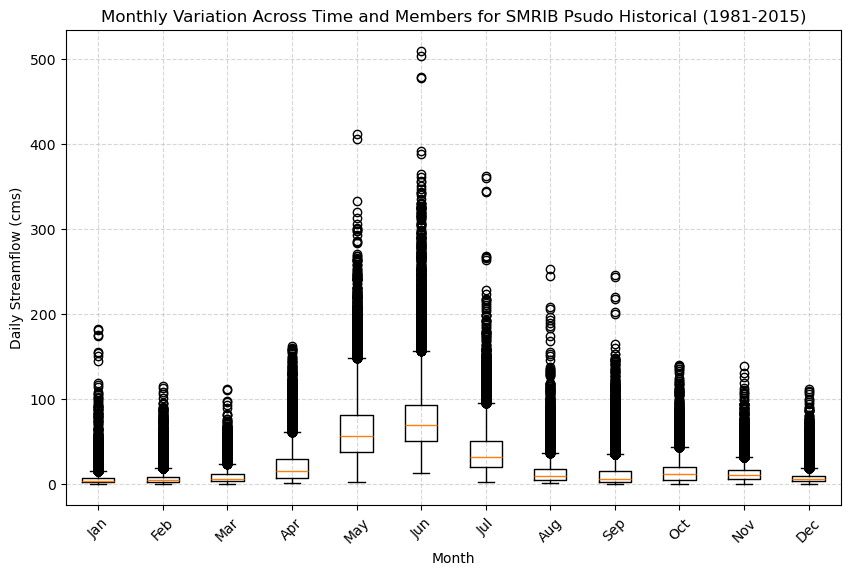

In [13]:
# Create boxplot
fig, ax = plt.subplots(figsize=(10, 6.18))
ax.boxplot(boxplot_data, tick_labels=[pd.to_datetime(str(i), format="%m").strftime("%b") for i in range(1, 13)])

# Labels and formatting
ax.set_title("Monthly Variation Across Time and Members for SMRIB Psudo Historical (1981-2015)")
ax.set_xlabel("Month")
ax.set_ylabel("Daily Streamflow (cms)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Plot 2

In [14]:
# Assuming `da` is your DataArray
stm_monthly_mean = stm_hist_trimmed.resample(DATE="ME").mean()  # Step 1: Take the mean for each month

# Step 2: Group by month (January, February, etc.) and take the mean
stm_final_monthly_mean = stm_monthly_mean.groupby("DATE.month").mean()

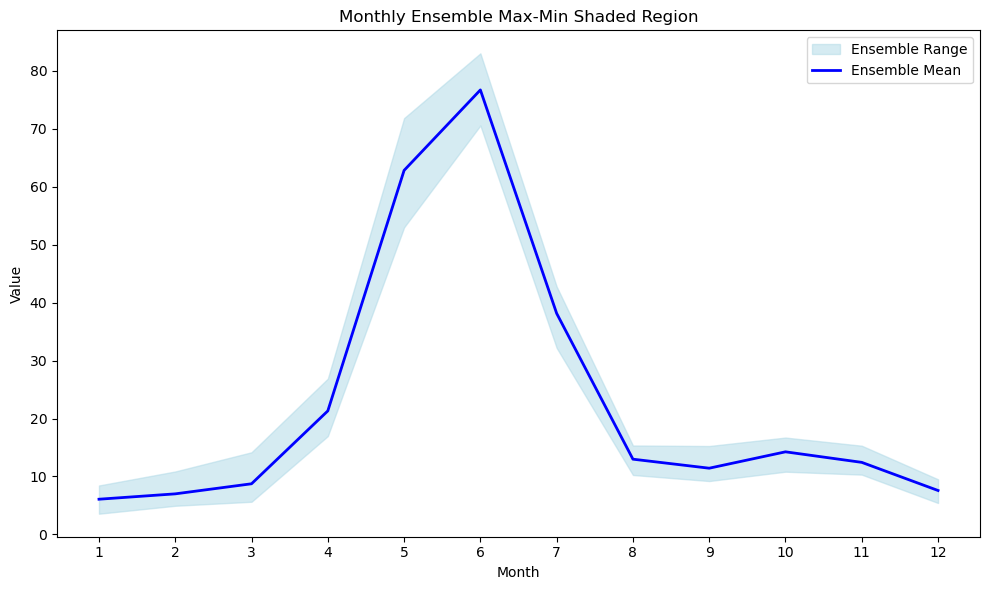

In [15]:
# Assuming `stm_final_monthly_mean` is your xarray.DataArray
# Get the max and min values across the ensemble (assuming "member" is the ensemble dimension)
monthly_max = stm_final_monthly_mean.max(dim='member')
monthly_min = stm_final_monthly_mean.min(dim='member')

# Get the months (1 to 12)
months = stm_final_monthly_mean.month

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the shaded region between the max and min
plt.fill_between(months, monthly_min, monthly_max, color='lightblue', alpha=0.5, label='Ensemble Range')

# Optionally, plot the mean (you can also modify this part as needed)
monthly_mean = stm_final_monthly_mean.mean(dim='member')
plt.plot(months, monthly_mean, color='blue', label='Ensemble Mean', linewidth=2)

# Customize the plot
plt.title("Monthly Ensemble Max-Min Shaded Region")
plt.xlabel("Month")
plt.ylabel("Value")
plt.xticks(np.arange(1, 13))  # To label months 1-12
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [16]:
def plot_monthly_uncertainty_both_subbasins(ensemble_results_dir, variables, start_year, end_year, hist_start, hist_end):
    # Define a dictionary for subbasin IDs based on variable names
    subbasin_ids = {
        "SMRIB": '58208',
        "MREIB": '58308',
    }

    num_vars = len(variables)  # Number of variables passed as input

    # Set up the figure with enough rows for each variable (two columns: SMRIB and MREIB)
    fig, axes = plt.subplots(num_vars, 2, figsize=(12, 6 * num_vars))  # 2 columns, n rows
    axes = axes.flatten()

    # Iterate over the variables
    for i, variable_name in enumerate(variables):
        # First, handle SMRIB
        subbasin_id_smrib = subbasin_ids["SMRIB"]
        
        # Extract ensemble data for SMRIB for the given variable
        data_smrib = extract_ensemble(ensemble_results_dir, subbasin_id_smrib, variable_name)
        
        # Process the data for SMRIB (Split by SSP245, SSP370, and Historical)
        data_smrib_ssp245 = data_smrib.sel(member=data_smrib.member.str.contains('ssp245'))
        data_smrib_ssp370 = data_smrib.sel(member=data_smrib.member.str.contains('ssp370'))
        data_smrib_hist = data_smrib.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Trim the data for the specified time range
        data_smrib_ssp245 = data_smrib_ssp245.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_smrib_ssp370 = data_smrib_ssp370.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_smrib_hist = data_smrib_hist.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Convert to float
        data_smrib_ssp245 = data_smrib_ssp245.astype(float)
        data_smrib_ssp370 = data_smrib_ssp370.astype(float)
        data_smrib_hist = data_smrib_hist.astype(float)

        # Resample to find monthly means
        monthly_mean_smrib_ssp245 = data_smrib_ssp245.resample(DATE='ME').mean()
        monthly_mean_smrib_ssp370 = data_smrib_ssp370.resample(DATE='ME').mean()
        monthly_mean_smrib_hist = data_smrib_hist.resample(DATE='ME').mean()

        # Group by month (January, February, etc.) and take the mean
        monthly_mean_smrib_ssp245 = monthly_mean_smrib_ssp245.groupby("DATE.month").mean()
        monthly_mean_smrib_ssp370 = monthly_mean_smrib_ssp370.groupby("DATE.month").mean()
        monthly_mean_smrib_hist = monthly_mean_smrib_hist.groupby("DATE.month").mean()

        # Get the max and min values for SMRIB SSP245
        monthly_mean_smrib_ssp245_max = monthly_mean_smrib_ssp245.max(dim='member')
        monthly_mean_smrib_ssp245_min = monthly_mean_smrib_ssp245.min(dim='member')

        # Get the max, min, and mean values for SMRIB SSP370
        monthly_mean_smrib_ssp370_max = monthly_mean_smrib_ssp370.max(dim='member')
        monthly_mean_smrib_ssp370_min = monthly_mean_smrib_ssp370.min(dim='member')

        # Get the max, min, and mean values for SMRIB Historical
        monthly_mean_smrib_hist_max = monthly_mean_smrib_hist.max(dim='member')
        monthly_mean_smrib_hist_min = monthly_mean_smrib_hist.min(dim='member')

        print(monthly_mean_smrib_ssp245)
            
        # Plot the shaded region for SMRIB between max and min
        axes[i * 2].fill_between(monthly_mean_smrib_ssp245['month'], monthly_mean_smrib_ssp245_min, monthly_mean_smrib_ssp245_max, color='blue', alpha=0.3, label=f'{variable_name} SMRIB SSP245 Range')
        axes[i * 2].fill_between(monthly_mean_smrib_ssp370['month'], monthly_mean_smrib_ssp370_min, monthly_mean_smrib_ssp370_max, color='green', alpha=0.3, label=f'{variable_name} SMRIB SSP370 Range')
        axes[i * 2].fill_between(monthly_mean_smrib_hist['month'], monthly_mean_smrib_hist_min, monthly_mean_smrib_hist_max, color='red', alpha=0.3, label=f'{variable_name} SMRIB Historical Range')
        
        axes[i * 2].set_title(f'Monthly Max/Min for {variable_name} SMRIB')
        axes[i * 2].set_xticks(range(0, 12))
        axes[i * 2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        axes[i * 2].set_xlabel('Month')
        axes[i * 2].set_ylabel(f'{variable_name} Range')
        axes[i * 2].legend()
        axes[i * 2].grid(True)

        # Then, handle MREIB
        subbasin_id_mreib = subbasin_ids["MREIB"]
        
        # Extract ensemble data for MREIB for the given variable
        data_mreib = extract_ensemble(ensemble_results_dir, subbasin_id_mreib, variable_name)
        
        # Process the data for MREIB (Split by SSP245, SSP370, and Historical)
        data_mreib_ssp245 = data_mreib.sel(member=data_mreib.member.str.contains('ssp245'))
        data_mreib_ssp370 = data_mreib.sel(member=data_mreib.member.str.contains('ssp370'))
        data_mreib_hist = data_mreib.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Trim the data for the specified time range
        data_mreib_ssp245 = data_mreib_ssp245.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_mreib_ssp370 = data_mreib_ssp370.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_mreib_hist = data_mreib_hist.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Convert to float
        data_mreib_ssp245 = data_mreib_ssp245.astype(float)
        data_mreib_ssp370 = data_mreib_ssp370.astype(float)
        data_mreib_hist = data_mreib_hist.astype(float)

        # Resample to find monthly means, then calculate max and min for each month
        monthly_mean_mreib_ssp245 = data_mreib_ssp245.resample(DATE='ME').mean()
        monthly_mean_mreib_ssp370 = data_mreib_ssp370.resample(DATE='ME').mean()
        monthly_mean_mreib_hist = data_mreib_hist.resample(DATE='ME').mean()

        # Group by month (January, February, etc.) and take the mean
        monthly_mean_mreib_ssp245 = monthly_mean_mreib_ssp245.groupby("DATE.month").mean()
        monthly_mean_mreib_ssp370 = monthly_mean_mreib_ssp370.groupby("DATE.month").mean()
        monthly_mean_mreib_hist = monthly_mean_mreib_hist.groupby("DATE.month").mean()

        # Get the max and min values for MREIB SSP245
        monthly_mean_mreib_ssp245_max = monthly_mean_mreib_ssp245.max(dim='member')
        monthly_mean_mreib_ssp245_min = monthly_mean_mreib_ssp245.min(dim='member')

        # Get the max, min, and mean values for MREIB SSP370
        monthly_mean_mreib_ssp370_max = monthly_mean_mreib_ssp370.max(dim='member')
        monthly_mean_mreib_ssp370_min = monthly_mean_mreib_ssp370.min(dim='member')

        # Get the max, min, and mean values for MREIB Historical
        monthly_mean_mreib_hist_max = monthly_mean_mreib_hist.max(dim='member')
        monthly_mean_mreib_hist_min = monthly_mean_mreib_hist.min(dim='member')

        # Plot the shaded region for MREIB between max and min
        axes[i * 2 + 1].fill_between(monthly_mean_mreib_ssp245['month'], monthly_mean_mreib_ssp245_min, monthly_mean_mreib_ssp245_max, color='blue', alpha=0.3, label=f'{variable_name} MREIB SSP245 Range')
        axes[i * 2 + 1].fill_between(monthly_mean_mreib_ssp370['month'], monthly_mean_mreib_ssp370_min, monthly_mean_mreib_ssp370_max, color='green', alpha=0.3, label=f'{variable_name} MREIB SSP370 Range')
        axes[i * 2 + 1].fill_between(monthly_mean_mreib_hist['month'], monthly_mean_mreib_hist_min, monthly_mean_mreib_hist_max, color='red', alpha=0.3, label=f'{variable_name} MREIB Historical Range')
        
        axes[i * 2 + 1].set_title(f'Monthly Max/Min for {variable_name} MREIB')
        axes[i * 2 + 1].set_xticks(range(0, 12))
        axes[i * 2 + 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        axes[i * 2 + 1].set_xlabel('Month')
        axes[i * 2 + 1].set_ylabel(f'{variable_name} Range')
        axes[i * 2 + 1].legend()
        axes[i * 2 + 1].grid(True)

    plt.tight_layout()
    plt.show()


In [41]:
def plot_monthly_uncertainty(ensemble_results_dir, variables, start_year, end_year, hist_start, hist_end, subbasin):
    # Define subbasin IDs for SMRIB and MREIB
    subbasin_ids = {
        "SMRIB": '58208',
        "MREIB": '58308',
    }

    # Check if the provided subbasin is valid
    if subbasin not in subbasin_ids:
        raise ValueError("Subbasin must be either 'SMRIB' or 'MREIB'.")

    # Number of variables passed as input
    num_vars = len(variables)  

    # Set up the figure with 3 columns (Historical, SSP245, SSP370) and n rows for variables
    fig, axes = plt.subplots(num_vars, 3, figsize=(14, 3.5 * num_vars))  # 3 columns, n rows
    axes = axes.flatten()

    # Subbasin ID
    subbasin_id = subbasin_ids[subbasin]

    # Iterate over the variables
    for i, variable_name in enumerate(variables):

                # Create a dictionary to map variables to corresponding names and units
        variable_dict = {
            'cout': {'name': 'Streamflow', 'unit': 'cms'},
            'upsnow': {'name': 'Mean Upstream SWE', 'unit': 'mm'},
            'upsoim': {'name': 'Mean Upstream Soil Moisture', 'unit': 'mm'},
            'upcprc': {'name': 'Precipitation', 'unit': 'mm/day'},
            'upctmp': {'name': 'Temperature', 'unit': 'C'}
        }
        
        # Assuming `variable` is one of the keys in the dictionary
        variable_realname = variable_dict[variable_name]['name']
        variable_unit = variable_dict[variable_name]['unit']

        # Extract ensemble data for the specified subbasin
        data = extract_ensemble(ensemble_results_dir, subbasin_id, variable_name)

                # Replace 0 values with NaN for precipitation ('upcprc')
        if variable_name == 'upcprc':
            data = data.where(data != 0, np.nan)

        # Process the data (Split by SSP245, SSP370, and Historical)
        data_ssp245 = data.sel(member=data.member.str.contains('ssp245'))
        data_ssp370 = data.sel(member=data.member.str.contains('ssp370'))
        data_hist = data.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Trim the data for the specified time range
        data_ssp245 = data_ssp245.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_ssp370 = data_ssp370.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_hist = data_hist.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Convert to float
        data_ssp245 = data_ssp245.astype(float)
        data_ssp370 = data_ssp370.astype(float)
        data_hist = data_hist.astype(float)

        # Resample to find monthly means
        monthly_mean_ssp245 = data_ssp245.resample(DATE='ME').mean()
        monthly_mean_ssp370 = data_ssp370.resample(DATE='ME').mean()
        monthly_mean_hist = data_hist.resample(DATE='ME').mean()

        # Group by month (January, February, etc.) and take the mean
        monthly_mean_ssp245 = monthly_mean_ssp245.groupby("DATE.month").mean()
        monthly_mean_ssp370 = monthly_mean_ssp370.groupby("DATE.month").mean()
        monthly_mean_hist = monthly_mean_hist.groupby("DATE.month").mean()

        # Get the max and min values for SSP245
        monthly_mean_ssp245_max = monthly_mean_ssp245.max(dim='member')
        monthly_mean_ssp245_min = monthly_mean_ssp245.min(dim='member')

        # Get the max, min, and mean values for SSP370
        monthly_mean_ssp370_max = monthly_mean_ssp370.max(dim='member')
        monthly_mean_ssp370_min = monthly_mean_ssp370.min(dim='member')

        # Get the max, min, and mean values for Historical
        monthly_mean_hist_max = monthly_mean_hist.max(dim='member')
        monthly_mean_hist_min = monthly_mean_hist.min(dim='member')

        # Calculate the mean values across the ensemble for each scenario
        monthly_mean_ssp245_mean = monthly_mean_ssp245.mean(dim='member')
        monthly_mean_ssp370_mean = monthly_mean_ssp370.mean(dim='member')
        monthly_mean_hist_mean = monthly_mean_hist.mean(dim='member')

        # Plot the shaded regions for each of the three scenarios (Historical, SSP245, SSP370)
        axes[i * 3].fill_between(monthly_mean_hist['month'], monthly_mean_hist_min, monthly_mean_hist_max, color='red', alpha=0.3, label=f'Range (1981-2015)')
        axes[i * 3 + 1].fill_between(monthly_mean_ssp245['month'], monthly_mean_ssp245_min, monthly_mean_ssp245_max, color='blue', alpha=0.3, label=f'Range (2015-2100)')
        axes[i * 3 + 2].fill_between(monthly_mean_ssp370['month'], monthly_mean_ssp370_min, monthly_mean_ssp370_max, color='green', alpha=0.3, label=f'Range (2015-2100)')

        # Plot the mean line for each scenario
        axes[i * 3].plot(monthly_mean_hist['month'], monthly_mean_hist_mean, color='red', linestyle='-', linewidth=1, label=f'Mean (1981-2015)')
        axes[i * 3 + 1].plot(monthly_mean_ssp245['month'], monthly_mean_ssp245_mean, color='blue', linestyle='-', linewidth=1, label=f'Mean (2015-2100)')
        axes[i * 3 + 2].plot(monthly_mean_ssp370['month'], monthly_mean_ssp370_mean, color='green', linestyle='-', linewidth=1, label=f'Mean (2015-2100)')

        # Titles, labels, legends, etc.
        axes[i * 3].set_title(f'Monthly Range and Mean for Pseudo-Historical {variable_realname} at {subbasin}', fontsize=9)
        axes[i * 3].set_xticks(range(0, 12))
        axes[i * 3].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],fontsize=8)
        axes[i * 3].set_xlabel('Month',fontsize=9)
        axes[i * 3].set_ylabel(f'{variable_realname} ({variable_unit})',fontsize=9)
        axes[i * 3].legend(fontsize=9)

        axes[i * 3 + 1].set_title(f'Monthly Range and Mean for SSP245 {variable_realname} at {subbasin}', fontsize=9)
        axes[i * 3 + 1].set_xticks(range(0, 12))
        axes[i * 3 + 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],fontsize=8)
        axes[i * 3 + 1].set_xlabel('Month',fontsize=9)
        axes[i * 3 + 1].set_ylabel(f'{variable_realname} ({variable_unit})',fontsize=9)
        axes[i * 3 + 1].legend(fontsize=9)

        axes[i * 3 + 2].set_title(f'Monthly Range (Max/Min) and Mean for SSP370 {variable_realname} at {subbasin}', fontsize=9)
        axes[i * 3 + 2].set_xticks(range(0, 12))
        axes[i * 3 + 2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],fontsize=8)
        axes[i * 3 + 2].set_xlabel('Month',fontsize=9)
        axes[i * 3 + 2].set_ylabel(f'{variable_realname} ({variable_unit})',fontsize=9)
        axes[i * 3 + 2].legend(fontsize=9)

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()


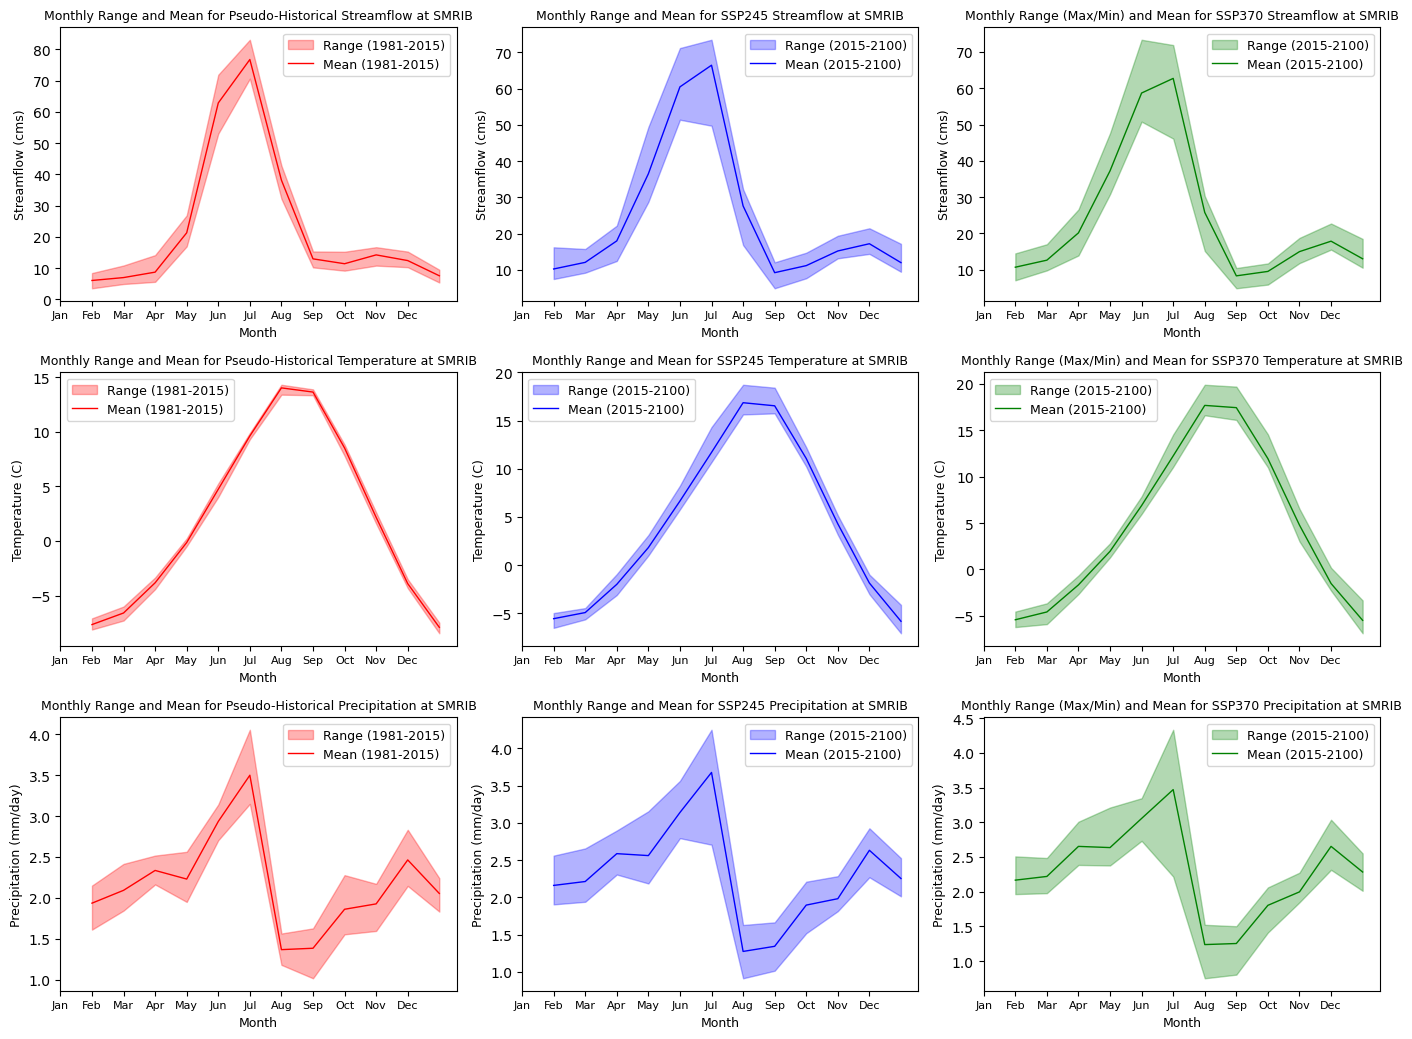

In [42]:
plot_monthly_uncertainty(results_directory, variables, start_year, end_year, hist_start, hist_end, 'SMRIB')

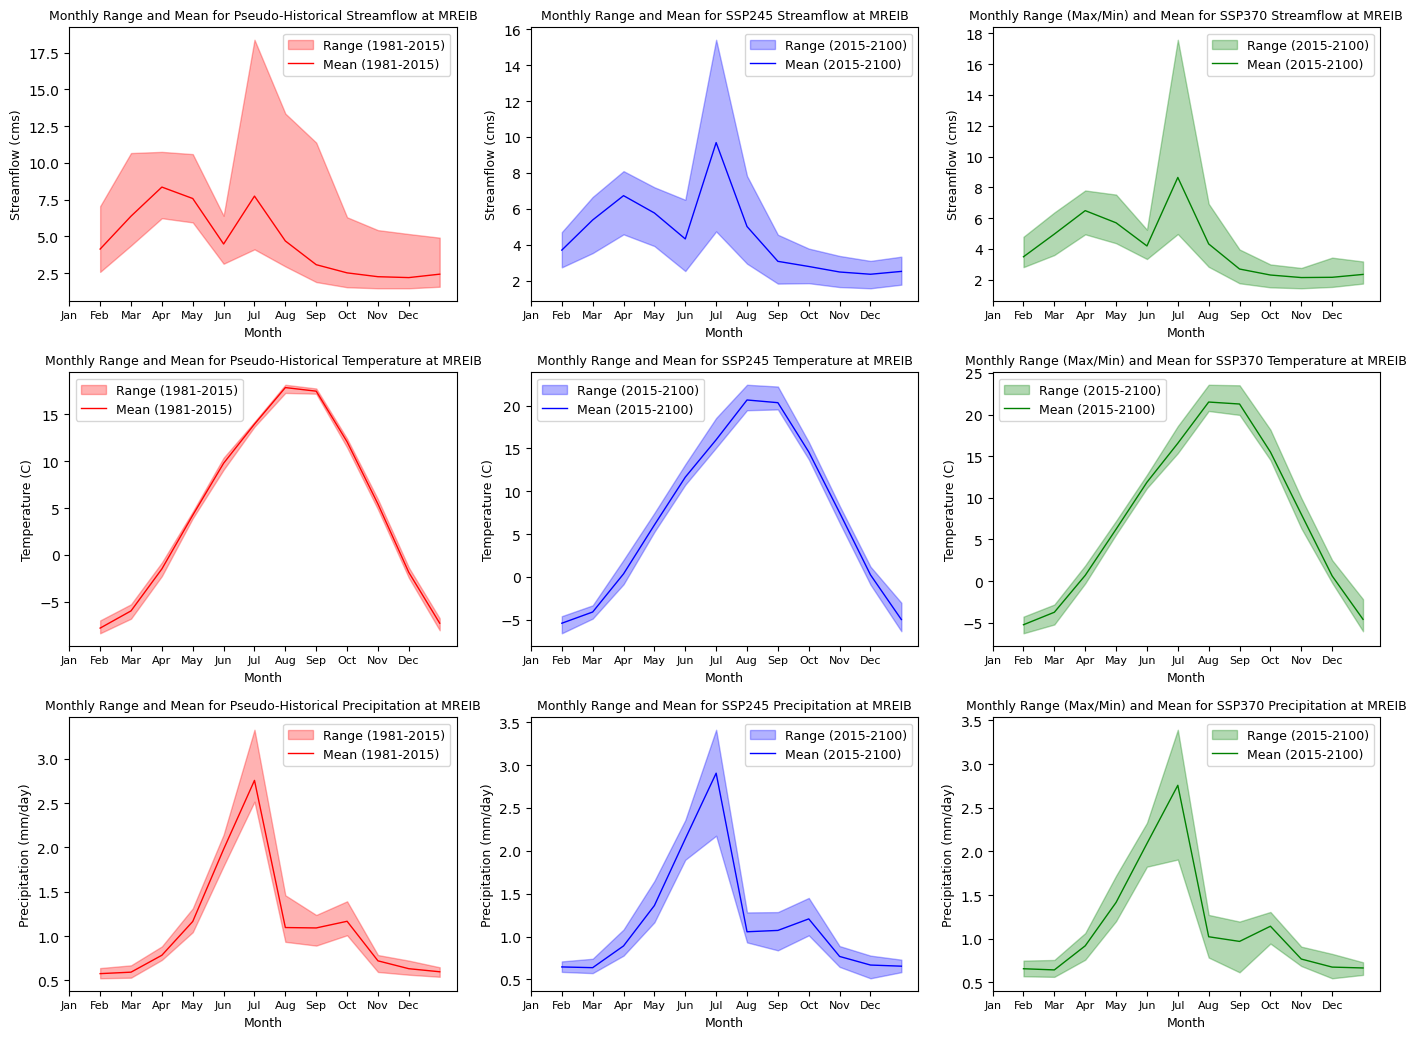

In [43]:
plot_monthly_uncertainty(results_directory, variables, start_year, end_year, hist_start, hist_end, 'MREIB')

In [ ]:
def plot_combined_monthly_uncertainty(ensemble_results_dir, variables, start_year, end_year, hist_start, hist_end, subbasin):
    # Define subbasin IDs for SMRIB and MREIB
    subbasin_ids = {
        "SMRIB": '58208',
        "MREIB": '58308',
    }

    # Check if the provided subbasin is valid
    if subbasin not in subbasin_ids:
        raise ValueError("Subbasin must be either 'SMRIB' or 'MREIB'.")

    num_vars = len(variables)  
    fig, axes = plt.subplots(num_vars, 1, figsize=(10, 4 * num_vars))  
    if num_vars == 1:
        axes = [axes]  # Ensure axes is iterable for a single variable

    subbasin_id = subbasin_ids[subbasin]

    for i, variable_name in enumerate(variables):
        ax = axes[i]

        # Create a dictionary to map variables to corresponding names and units
        variable_dict = {
            'cout': {'name': 'Streamflow', 'unit': 'cms'},
            'upsnow': {'name': 'Mean Upstream SWE', 'unit': 'mm'},
            'upsoim': {'name': 'Mean Upstream Soil Moisture', 'unit': 'mm'},
            'upcprc': {'name': 'Precipitation', 'unit': 'mm/day'},
            'upctmp': {'name': 'Temperature', 'unit': 'C'}
        }
        
        # Assuming `variable` is one of the keys in the dictionary
        variable_realname = variable_dict[variable_name]['name']
        variable_unit = variable_dict[variable_name]['unit']

        
        # Extract ensemble data for the specified subbasin
        data = extract_ensemble(ensemble_results_dir, subbasin_id, variable_name)

        # Filter members by scenario
        data_ssp245 = data.sel(member=data.member.str.contains('ssp245'))
        data_ssp370 = data.sel(member=data.member.str.contains('ssp370'))
        data_hist = data.sel(DATE=slice(f'{hist_start}-01-01', f'{hist_end}-12-31'))

        # Trim to selected years
        data_ssp245 = data_ssp245.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
        data_ssp370 = data_ssp370.sel(DATE=slice(f'{start_year}-01-01', f'{end_year}-12-31'))

        # Convert to float
        data_ssp245 = data_ssp245.astype(float)
        data_ssp370 = data_ssp370.astype(float)
        data_hist = data_hist.astype(float)

        # Resample to monthly means
        monthly_mean_ssp245 = data_ssp245.resample(DATE='ME').mean()
        monthly_mean_ssp370 = data_ssp370.resample(DATE='ME').mean()
        monthly_mean_hist = data_hist.resample(DATE='ME').mean()

        # Group by month and compute statistics
        monthly_mean_ssp245 = monthly_mean_ssp245.groupby("DATE.month").mean()
        monthly_mean_ssp370 = monthly_mean_ssp370.groupby("DATE.month").mean()
        monthly_mean_hist = monthly_mean_hist.groupby("DATE.month").mean()

        # Compute max, min, and mean
        ssp245_max, ssp245_min, ssp245_mean = monthly_mean_ssp245.max(dim='member'), monthly_mean_ssp245.min(dim='member'), monthly_mean_ssp245.mean(dim='member')
        ssp370_max, ssp370_min, ssp370_mean = monthly_mean_ssp370.max(dim='member'), monthly_mean_ssp370.min(dim='member'), monthly_mean_ssp370.mean(dim='member')
        hist_max, hist_min, hist_mean = monthly_mean_hist.max(dim='member'), monthly_mean_hist.min(dim='member'), monthly_mean_hist.mean(dim='member')

      #  print(ssp245_mean)

        # Plot SSP245
        ax.fill_between(ssp245_mean['month'], ssp245_min, ssp245_max, color='blue', alpha=0.3, label='SSP245 Range')
        ax.plot(ssp245_mean['month'], ssp245_mean, color='blue', linestyle='-', linewidth=1.5, label='SSP245 Mean')

        # Plot SSP370
        ax.fill_between(ssp370_mean['month'], ssp370_min, ssp370_max, color='green', alpha=0.3, label='SSP370 Range')
        ax.plot(ssp370_mean['month'], ssp370_mean, color='green', linestyle='-', linewidth=1.5, label='SSP370 Mean')

        # Plot Historical
        ax.fill_between(hist_mean['month'], hist_min, hist_max, color='red', alpha=0.3, label='Historical Range (1981-2015)')
        ax.plot(hist_mean['month'], hist_mean, color='red', linestyle='-', linewidth=1.5, label='Historical Mean')

        # Labels and titles
        ax.set_title(f'Monthly Uncertainty for {variable_realname} ({subbasin})')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        ax.set_xlabel('Month')
        ax.set_ylabel(f'{variable_realname} ({variable_unit})')
        ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# plot_combined_monthly_uncertainty(results_directory, variables, start_year, end_year, hist_start, hist_end, 'SMRIB')

In [ ]:
# plot_combined_monthly_uncertainty(results_directory, variables, start_year, end_year, hist_start, hist_end, 'MREIB')